In [ ]:
import pandas as pd

from lib.utils.file_io import *
from lib.utils.statistics import *
from lib.utils.datetime_handler import calc_rel_period
from lib.visualization.plot_generator import PlotGen

import matplotlib as mpl
import lib.visualization.figure_setting as figure_setting
mpl.rcParams.update(figure_setting.fig_setting)
import matplotlib.pyplot as plt







In [3]:
def compute_N_by_week(lang, df, period_col='rel_week', weight_col='tot_pct'):
    N = df.groupby(period_col)[weight_col].sum().reset_index()
    N.columns = ["rel_week", "n_docs"]
    N["language"] = lang
    return N


In [4]:
tot_df = pd.DataFrame()
for idx, lang in enumerate(CONSTANTS.languages_from2020to2022) :
    plotgen = PlotGen(idx = 100+idx, model_in_run='tag')
    print(f'[Start....] Aggreagate data for {lang} language')

    tmp = load_df(plotgen.data_dir, ['cdate' , 'id' , 'tag', 'cnt', 'tot_cnt', 'pct'])
    tmp = calc_rel_period(tmp, plotgen.std_date, date_col = 'cdate', period = 7).reset_index()
    tmp = compute_N_by_week(lang, tmp, weight_col='pct')
    tot_df = pd.concat([tot_df, tmp], axis = 0)
    
df = tot_df.groupby(['rel_week'])['n_docs'].sum().reset_index()

[Start....] Aggreagate data for python language
[Start....] Aggreagate data for javascript language
[Start....] Aggreagate data for java language
[Start....] Aggreagate data for c# language
[Start....] Aggreagate data for c++ language
[Start....] Aggreagate data for c language
[Start....] Aggreagate data for r language
[Start....] Aggreagate data for php language
[Start....] Aggreagate data for swift language
[Start....] Aggreagate data for kotlin language
[Start....] Aggreagate data for dart language
[Start....] Aggreagate data for typescript language
[Start....] Aggreagate data for go language
[Start....] Aggreagate data for ruby language
[Start....] Aggreagate data for rust language
[Start....] Aggreagate data for scala language
[Start....] Aggreagate data for julia language
[Start....] Aggreagate data for matlab language
[Start....] Aggreagate data for groovy language
[Start....] Aggreagate data for objective-c language
[Start....] Aggreagate data for vb.net language
[Start....] Ag

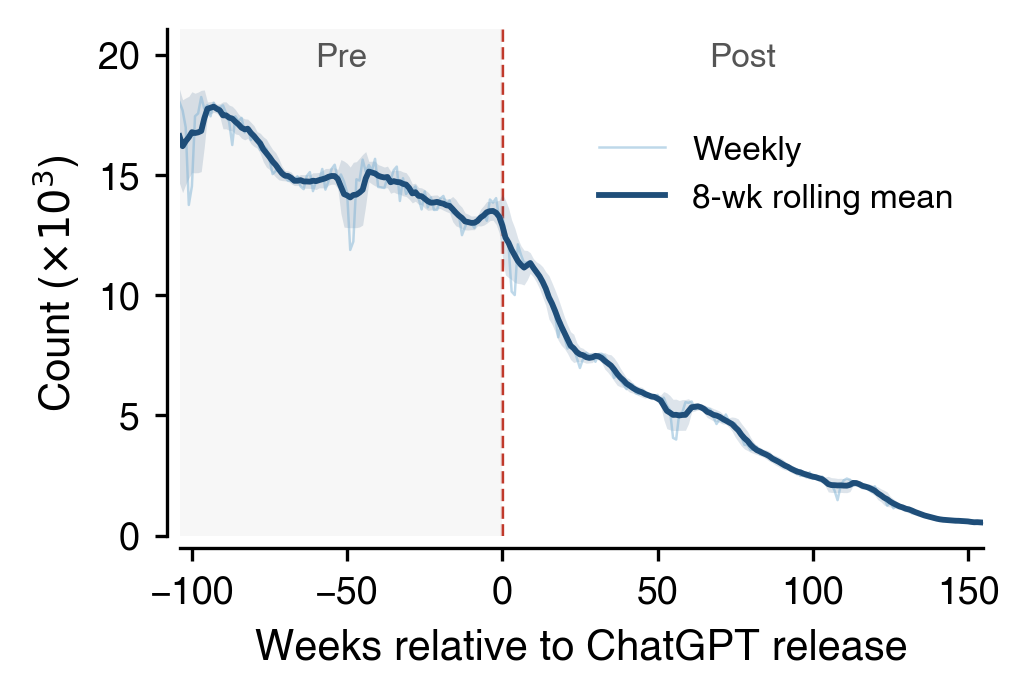

In [8]:
VALUE_COL    = 'n_docs'                       
TIME_COL     = 'rel_week'                    
YLABEL       = r'Count ($\times 10^{3}$)'   
XLABEL       = 'Weeks relative to ChatGPT release' 
EVENT_LABEL  = 'Event'                     
SMOOTH_WIN   = 8                             
Y_SCALE      = 1000                          

OUT_PNG = 'figure.png'
OUT_PDF = 'figure.pdf'



# ============================================================
# 3. Smoothing & 신뢰구간
# ============================================================
df = df.sort_values(TIME_COL).reset_index(drop=True)
x = df[TIME_COL].values
y = df[VALUE_COL].values.astype(float)

y_smooth = pd.Series(y).rolling(SMOOTH_WIN, center=True, min_periods=1).mean().values
y_std    = pd.Series(y).rolling(SMOOTH_WIN, center=True, min_periods=1).std().values

# ============================================================
# 4. Plot
# ============================================================
fig, ax = plt.subplots(figsize=(3.5, 2.4), dpi=300)   # single column ~89mm

# Pre 구간 배경
ax.axvspan(x.min(), 0, color='#F2F2F2', alpha=0.6, lw=0)

# Raw 시계열 (옅게)
ax.plot(x, y, color='#7FB3D5', lw=0.6, alpha=0.5, label='Weekly')


# ±1 SD band
ax.fill_between(x, y_smooth - y_std, y_smooth + y_std,
                color='#1f4e79', alpha=0.15, lw=0)

# Smoothed line
ax.plot(x, y_smooth, color='#1f4e79', lw=1.4,
        label=f'{SMOOTH_WIN}-wk rolling mean')

# 이벤트 표시
ax.axvline(0, color='#C0392B', lw=0.8, ls='--', zorder=0)
ymax = np.nanmax(y) * 1.05
# ax.annotate(EVENT_LABEL, xy=(0, ymax), xytext=(15, ymax),
#             fontsize=8, color='#C0392B', va='center',
#             arrowprops=dict(arrowstyle='-', color='#C0392B', lw=0.6))

# Pre/Post 라벨
ax.text(x.min() + (0 - x.min()) / 2, ymax * 1.02,
        'Pre', fontsize=8, color='#555', ha='center')
ax.text((x.max() + 0) / 2, ymax * 1.02,
        'Post', fontsize=8, color='#555', ha='center')

# Spine 정리
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
ax.spines['left'].set_position(('outward', 3))
ax.spines['bottom'].set_position(('outward', 3))

# 축 라벨
ax.set_xlabel(XLABEL)
ax.set_ylabel(YLABEL)

# y축 스케일링 (×10³ 표기)
yticks = ax.get_yticks()
ax.set_yticks(yticks)
ax.set_yticklabels([f'{t/Y_SCALE:g}' for t in yticks])
ax.set_xlim(x.min(), x.max())
ax.set_ylim(0, ymax * 1.1)

ax.legend(loc='upper right', bbox_to_anchor=(1, 0.85))

plt.tight_layout()
# plt.savefig(OUT_PNG, dpi=300, bbox_inches='tight', facecolor='white')
# plt.savefig(OUT_PDF,           bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 6))

# 산점도
ax.scatter(df["log_n_docs"], df["post_t"]*100,  # %로 변환
           s=80, alpha=0.7, edgecolor="steelblue", facecolor="lightblue")

# 라벨
for _, row in df.iterrows():
    ax.annotate(row["language"], (row["log_n_docs"], row["post_t"]*100),
                fontsize=9, xytext=(5, 3), textcoords="offset points")

# OLS 적합선 + CI
x_grid = np.linspace(df["log_n_docs"].min(), df["log_n_docs"].max(), 100)
pred = m2.get_prediction(pd.DataFrame({"log_n_docs": x_grid}))
pred_df = pred.summary_frame(alpha=0.05)

ax.plot(x_grid, pred_df["mean"]*100, "--", color="crimson", lw=2)
ax.fill_between(x_grid, pred_df["mean_ci_lower"]*100, pred_df["mean_ci_upper"]*100,
                color="crimson", alpha=0.15, label="95% CI")

ax.axhline(0, color="gray", lw=0.5, ls=":")
ax.set_xlabel("Pre-GPT accumulated questions (log$_{10}$)")
ax.set_ylabel("Post-GPT slope (% per week)")
ax.legend(title=f"OLS: slope = {m2.params['log_n_docs']*100:.2f}\n"
                f"$R^2$ = {m2.rsquared:.2f}, $p$ < {m2.pvalues['log_n_docs']:.3f}")
plt.tight_layout()